# FER2013 Data Preprocessing - Phase 1

Clean preprocessing notebook with exact Phase 1 configuration:
- No data augmentation (Phase 1 trains on clean data)
- Uses ResNet50 `preprocess_input` (CRITICAL FIX)
- Proper train/validation split
- Class distribution analysis

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input
import json

print('All libraries imported successfully')

All libraries imported successfully


## Configuration

In [4]:
# Paths
PROJECT_ROOT = Path('/Users/nadaashraf/Desktop/FER copy')
DATA_DIR = PROJECT_ROOT / 'data' / 'fer2013'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

# Image parameters
IMG_SIZE = 224  # ResNet50 input size
BATCH_SIZE = 32
SEED = 42

# Emotion labels
EMOTIONS = ['Angry', 'Contempt', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
NUM_CLASSES = len(EMOTIONS)

print(f'Project root: {PROJECT_ROOT}')
print(f'Data directory: {DATA_DIR}')
print(f'Number of classes: {NUM_CLASSES}')

Project root: /Users/nadaashraf/Desktop/FER copy
Data directory: /Users/nadaashraf/Desktop/FER copy/data/fer2013
Number of classes: 8


## Load and Explore Dataset

In [5]:
# Check data structure
train_dir = DATA_DIR / 'train'
test_dir = DATA_DIR / 'test'

print(f'Train directory exists: {train_dir.exists()}')
print(f'Test directory exists: {test_dir.exists()}')

# Count images per class
print('\nTraining set class distribution:')
for emotion in EMOTIONS:
    emotion_dir = train_dir / emotion
    if emotion_dir.exists():
        count = len(list(emotion_dir.glob('*.jpg'))) + len(list(emotion_dir.glob('*.png')))
        print(f'{emotion}: {count} images')

Train directory exists: True
Test directory exists: True

Training set class distribution:
Angry: 8000 images
Contempt: 8000 images
Disgust: 8000 images
Fear: 8000 images
Happy: 8000 images
Neutral: 10379 images
Sad: 8000 images
Surprise: 8000 images


## Create Data Generators

**Phase 1 Configuration:**
- NO data augmentation
- Only ResNet50 `preprocess_input` normalization
- Train on clean data to establish baseline

In [6]:
# Phase 1: No augmentation, only preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # CRITICAL: ResNet50 preprocessing
    validation_split=0.2  # 80% train, 20% validation
)

# Test data generator (no augmentation)
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

print('Data generators created (Phase 1: No augmentation)')

Data generators created (Phase 1: No augmentation)


In [7]:
# Training generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

# Validation generator
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

# Test generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f'Training samples: {train_generator.samples}')
print(f'Validation samples: {val_generator.samples}')
print(f'Test samples: {test_generator.samples}')

Found 53104 images belonging to 8 classes.
Found 13275 images belonging to 8 classes.
Found 3573 images belonging to 8 classes.
Training samples: 53104
Validation samples: 13275
Test samples: 3573


## Visualize Sample Images

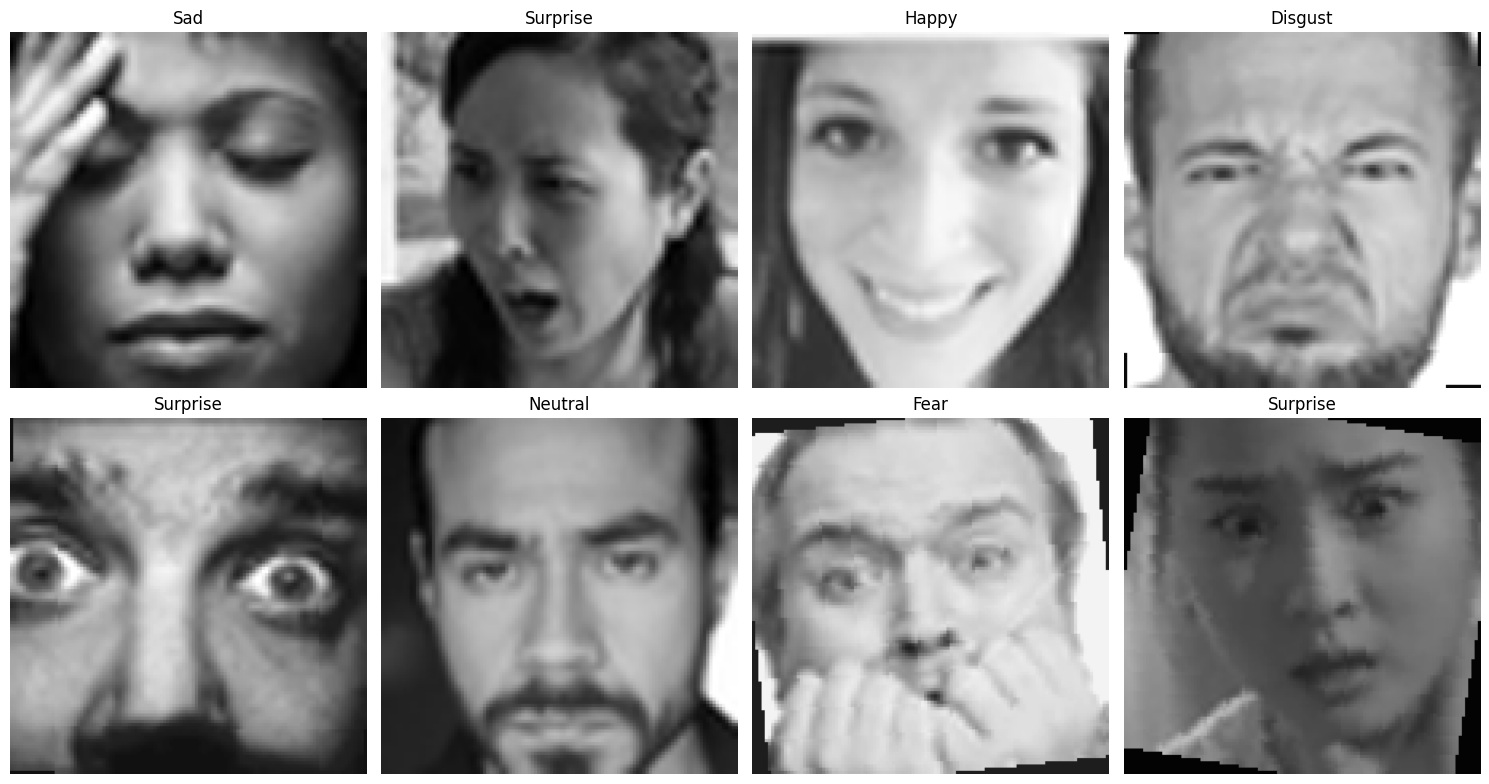

Sample images saved to /Users/nadaashraf/Desktop/FER copy/outputs/sample_images.png


In [8]:
# Get a batch of images
sample_batch, sample_labels = next(train_generator)

# Plot sample images
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.ravel()

for i in range(8):
    # Denormalize image for display
    img = sample_batch[i]
    # Reverse ResNet preprocessing: add mean and scale
    img = img.copy()
    img[:, :, 0] += 103.939
    img[:, :, 1] += 116.779
    img[:, :, 2] += 123.68
    img = img[:, :, ::-1]  # BGR to RGB
    img = np.clip(img / 255.0, 0, 1)  # Normalize to [0, 1]
    
    label_idx = np.argmax(sample_labels[i])
    emotion = EMOTIONS[label_idx]
    
    axes[i].imshow(img)
    axes[i].set_title(emotion)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Sample images saved to {OUTPUT_DIR / "sample_images.png"}')

## Class Distribution Analysis

In [9]:
# Get class distribution from generator
class_indices = train_generator.class_indices
print('Class indices:', class_indices)

# Reverse mapping
indices_to_class = {v: k for k, v in class_indices.items()}

# Count samples per class
train_class_counts = {}
for class_idx, class_name in indices_to_class.items():
    count = np.sum(train_generator.classes == class_idx)
    train_class_counts[class_name] = count

print('\nTraining set distribution:')
for emotion, count in sorted(train_class_counts.items()):
    print(f'{emotion}: {count} images ({count/train_generator.samples*100:.1f}%)')

Class indices: {'Angry': 0, 'Contempt': 1, 'Disgust': 2, 'Fear': 3, 'Happy': 4, 'Neutral': 5, 'Sad': 6, 'Surprise': 7}

Training set distribution:
Angry: 6400 images (12.1%)
Contempt: 6400 images (12.1%)
Disgust: 6400 images (12.1%)
Fear: 6400 images (12.1%)
Happy: 6400 images (12.1%)
Neutral: 8304 images (15.6%)
Sad: 6400 images (12.1%)
Surprise: 6400 images (12.1%)


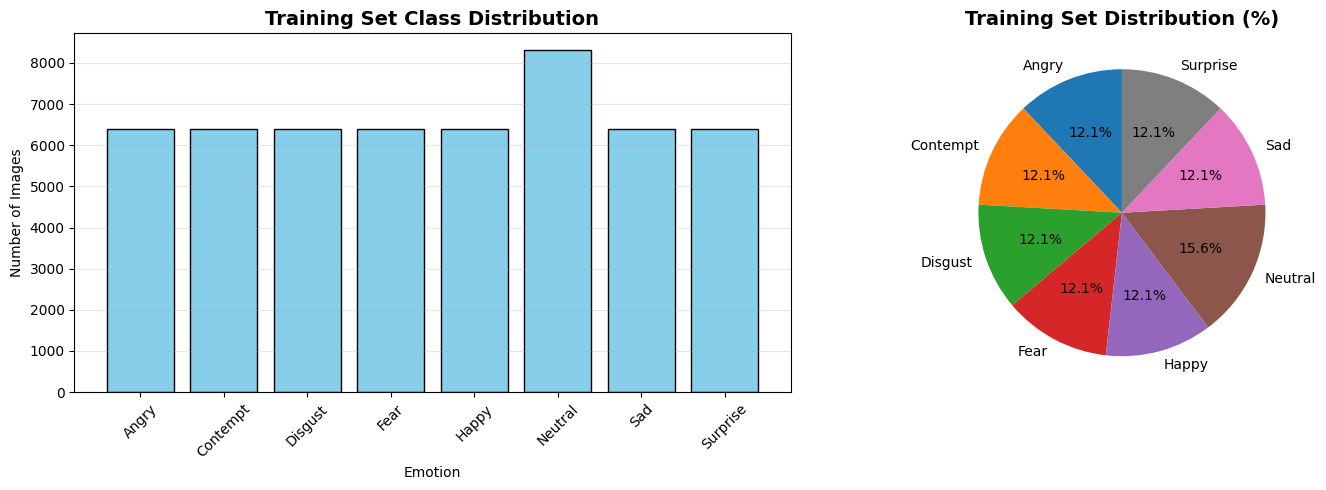

Class distribution plot saved to /Users/nadaashraf/Desktop/FER copy/outputs/class_distribution.png


In [10]:
# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training distribution
emotions = list(train_class_counts.keys())
counts = list(train_class_counts.values())

axes[0].bar(emotions, counts, color='skyblue', edgecolor='black')
axes[0].set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(counts, labels=emotions, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Training Set Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Class distribution plot saved to {OUTPUT_DIR / "class_distribution.png"}')

## Save Configuration

In [11]:
# Save class indices for later use
with open(PROJECT_ROOT / 'class_indices.json', 'w') as f:
    json.dump(class_indices, f, indent=2)

print(f'Class indices saved to {PROJECT_ROOT / "class_indices.json"}')

# Save preprocessing configuration
config = {
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'num_classes': NUM_CLASSES,
    'emotions': EMOTIONS,
    'augmentation': 'None (Phase 1)',
    'preprocessing': 'ResNet50 preprocess_input',
    'train_samples': int(train_generator.samples),
    'val_samples': int(val_generator.samples),
    'test_samples': int(test_generator.samples)
}

with open(OUTPUT_DIR / 'preprocessing_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f'Preprocessing config saved to {OUTPUT_DIR / "preprocessing_config.json"}')

Class indices saved to /Users/nadaashraf/Desktop/FER copy/class_indices.json
Preprocessing config saved to /Users/nadaashraf/Desktop/FER copy/outputs/preprocessing_config.json


## Summary

**Phase 1 Preprocessing Complete:**
- ✅ Data loaded from FER2013 dataset
- ✅ ResNet50 `preprocess_input` applied (CRITICAL FIX)
- ✅ No data augmentation (clean baseline)
- ✅ 80/20 train/validation split
- ✅ Class distribution analyzed
- ✅ Configuration saved

**Ready for:** Model development and Phase 1 training